# Практическое задание: Классификация временных рядов (Time Series Classification)

**Цель обучения:**
Познакомиться с основными парадигмами классификации временных рядов (dictionary-based, shapelet-based, feature-based) и базовыми принципами работы с нейросетевыми архитектурами (1D-CNN) для временных рядов. Научиться применять продвинутые методы извлечения признаков и анализировать результаты их работы.

---

## **Задание №1: Теоретические вопросы**
Ответьте на следующие вопросы кратко (2-3 предложения):

1. В чём принципиальная разница между методами SAX (Symbolic Aggregate approXimation) и SFA (Symbolic Fourier Approximation)? Какой из них лучше справляется с зашумленными данными и почему?

SAX преобразует временной ряд в символьную строку через кусочно-постоянное приближение (PAA) и квантование по нормальному распределению. SFA делает то же самое, но сначала применяет дискретное преобразование Фурье. Именно поэтому SFA лучше справляется с зашумленными данными: преобразование Фурье естественным образом разделяет сигнал и шум (шум концентрируется в высокочастотных компонентах), и SFA просто отбрасывает эти компоненты, оставляя только информативные низкочастотные коэффициенты.

2. Как алгоритм BOSS (Bag-of-SFA Symbols) (или его модификации, например WEASEL) использует концепцию TF-IDF для временных рядов? В чем смысл такого подхода?

BOSS строит гистограмму SFA-слов для каждого временного ряда, а WEASEL дополнительно применяет TF-IDF-взвешивание: слова, которые часто встречаются во всех классах, получают низкий вес, а слова, характерные для конкретного класса высокий. Смысл в том, чтобы автоматически выделить дискриминативные паттерны: если какой-то локальный фрагмент формы ряда встречается почти везде, он неинформативен; если же он специфичен для одного класса — он важен для классификации.

3. Что такое shapelet (шейплет) временного ряда? В чем преимущество алгоритма ROCKET по сравнению с классическими методами поиска шейплетов?

Шейплет это короткий подпоследовательный фрагмент временного ряда, максимально хорошо разделяющий классы по минимальному расстоянию до него. Классические методы поиска шейплетов требуют перебора экспоненциального числа кандидатов, что долго. ROCKET вместо целенаправленного поиска генерирует десятки тысяч случайных свёрточных ядер разной длины и дилатации, извлекая из каждого два признака (max и доля положительных активаций — PPV) это позволяет охватить огромное пространство паттернов за линейное время.

4. Модель `catch22` извлекает 22 признака из временного ряда. Зачем использовать фиксированные признаки, если можно обучить глубокую нейросеть (CNN) извлекать их автоматически?

Фиксированные 22 признака catch22 это интерпретируемые, теоретически обоснованные характеристики: энтропия, автокорреляция, нелинейные показатели и т.д., которые работают хорошо уже на малых выборках, не требуют GPU и не переобучаются. Глубокая CNN, напротив, требует большого количества данных, и долгого обучения. На небольших датасетах она переобучается и уступает catch22.


5. Почему сверточные нейронные сети (1D-CNN) эффективны для задач классификации временных рядов? Какую роль в них играют многоветвевые (multi-branch) преобразования (например, Inception Time)?

Одномерные свёрточные сети эффективны для временных рядов, потому что локальные ядра обнаруживают повторяющиеся паттерны независимо от их положения во времени, а иерархия слоев позволяет строить признаки разного масштаба — от коротких всплесков до долгих трендов. InceptionTime расширяет эту идею: в каждом блоке параллельно применяются ядра разных размеров, что позволяет одновременно захватывать паттерны на разных временных масштабах без ручного выбора размера окна, повышая точность и устойчивость модели.

# Часть 2: Практическая реализация и сравнение методов

## **Задание № 2:** Сравнить 3 подхода к классификации временных рядов на простом наборе данных `GunPoint` или любом другом стандартном датасете из библиотеки `sktime`.

**Необходимые библиотеки:**
- `sktime` (понадобится для ROCKET и BOSS/WEASEL)
- `catch22` или пакет `tsfel`
- `numpy`, `pandas`, `sklearn`, `matplotlib`
- `tensorflow` или `pytorch` (для 1D-CNN)

In [3]:
!pip install sktime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.3/36.3 MB 35.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.8/159.8 kB 7.4 MB/s eta 0:00:00


X_train shape: (147, 1, 251)
X_test shape: (64, 1, 251)


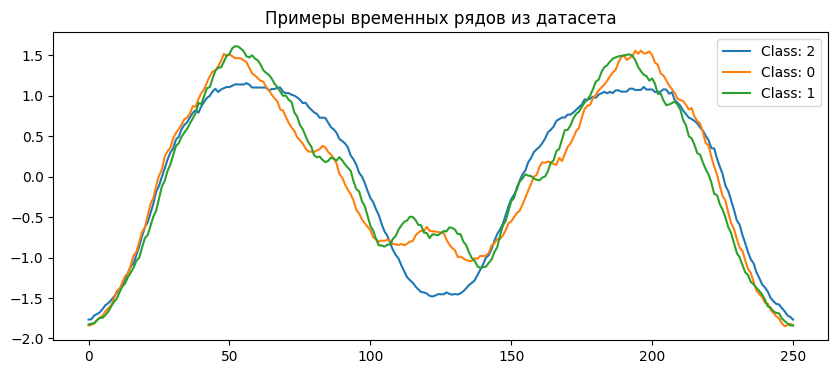

In [4]:
# Загрузка и подготовка данных
from sktime.datasets import load_arrow_head
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

# Мы используем датасет ArrowHead (форма наконечников стрел) или любой другой из UCR
X, y = load_arrow_head(return_type="numpy3d")
# X имеет форму (Кол-во образцов, кол-во каналов=1, длина ряда)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

# Отрисовка пары примеров временных рядов разных классов
plt.figure(figsize=(10, 4))
for i in range(3):
    plt.plot(X_train[i, 0, :], label=f"Class: {y_train[i]}")
plt.title("Примеры временных рядов из датасета")
plt.legend()
plt.show()

### Задание 2.1: Классификация с помощью алгоритма ROCKET (Shapelets/Convolutions)

Используйте класс `RocketClassifier` из библиотеки `sktime`. Этот алгоритм генерирует случайные свертки для извлечения признаков и использует Ridge Regression для классификации.

**Задание:**
1. Подключите `RocketClassifier` из `sktime.classification.kernel_based`. Обучите его на `X_train`, `y_train`.
2. Предскажите классы для `X_test` и посчитайте `accuracy_score`. Замерьте время обучения.

In [5]:
from sktime.classification.kernel_based import RocketClassifier
import time

rocket_clf = RocketClassifier(num_kernels=10000, random_state=42)

start = time.time()
rocket_clf.fit(X_train, y_train)
rocket_train_time = time.time() - start

y_pred_rocket = rocket_clf.predict(X_test)
rocket_acc = accuracy_score(y_test, y_pred_rocket)

print(f"Время обучения ROCKET: {rocket_train_time:.2f} сек")
print(f"Accuracy ROCKET:       {rocket_acc:.4f}")
print()
print(classification_report(y_test, y_pred_rocket))


Время обучения ROCKET: 48.26 сек
Accuracy ROCKET:       0.9375

              precision    recall  f1-score   support

           0       0.93      0.96      0.95        28
           1       0.94      0.94      0.94        17
           2       0.94      0.89      0.92        19

    accuracy                           0.94        64
   macro avg       0.94      0.93      0.94        64
weighted avg       0.94      0.94      0.94        64



### Задание № 2.2: Использование алгоритма на основе словарей (Dictionary-based: cBOSS / WEASEL)

Теперь протестируйте класс `BOSSEnsemble` или `ContractableBOSS` из библиотеки `sktime` (раздел `dictionary_based`).
Эти методы преобразуют временные ряды в дискретные слова (алфавит) с использованием скользящего окна (SFA), и оценивают частость.

**Задание:**
1. Подключите любую модель BOSS-семейства.
2. Проведите обучение и вычислите метрику `accuracy_score`. Сравните время обучения с ROCKET.

In [6]:
from sktime.classification.dictionary_based import ContractableBOSS

cboss_clf = ContractableBOSS(
    n_parameter_samples=250,
    max_ensemble_size=50,
    random_state=42,
)

start = time.time()
cboss_clf.fit(X_train, y_train)
cboss_train_time = time.time() - start

y_pred_cboss = cboss_clf.predict(X_test)
cboss_acc = accuracy_score(y_test, y_pred_cboss)

print(f"Время обучения cBOSS: {cboss_train_time:.2f} сек")
print(f"Accuracy cBOSS:       {cboss_acc:.4f}")
print()
print(classification_report(y_test, y_pred_cboss))

Время обучения cBOSS: 52.48 сек
Accuracy cBOSS:       0.9531

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        28
           1       0.89      0.94      0.91        17
           2       0.94      0.89      0.92        19

    accuracy                           0.95        64
   macro avg       0.94      0.95      0.94        64
weighted avg       0.95      0.95      0.95        64



### Задание №2.3: Глубокая архитектура для временных рядов (1D-CNN) (с помощью PyTorch)

Создайте простую свёрточную сеть с использованием 1D свёрток. Нейросети для 1D рядов похожи на 2D-сети (картинки), но срез окна проходит вдоль временной оси. Суть использования CNN-архитектур - извлечение сложных локальных и глобальных признаков (features) из формы временного ряда.

**Задание:**
1. Подготовьте данные для фреймворка (PyTorch).
2. Напишите 2-3 слоя `Conv1D` + `ReLU` + `MaxPooling1D`, затем `Flatten` и выходной слой `Dense` c функцией Softmax.
3. Обучите модель в течение небольшого количества эпох, подсчитайте `accuracy` на тестовом наборе. Сравните с классическими методами (Rocket, BOSS).

In [7]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import LabelEncoder
import time
import matplotlib.pyplot as plt

In [8]:
# 1. Построение простой архитектуры 1D-CNN
class Simple1DCNN(nn.Module):
    def __init__(self, num_classes):
        super(Simple1DCNN, self).__init__()
        # Входной канал = 1 (так как у нас одномерный временной ряд)
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=32, kernel_size=3)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool1d(kernel_size=2)

        self.conv2 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool1d(kernel_size=2)

        self.flatten = nn.Flatten()

        # Вычисляем размер после сверток и пулинга (для ArrowHead с длиной 251)
        # После conv1: 251 - 3 + 1 = 249. pool1: 249 // 2 = 124
        # После conv2: 124 - 3 + 1 = 122. pool2: 122 // 2 = 61
        # Итого: 64 канала * 61 = 3904
        self.fc1 = nn.Linear(64 * 61, 128)
        self.relu3 = nn.ReLU()
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.flatten(x)
        x = self.relu3(self.fc1(x))
        x = self.fc2(x)
        return x

In [19]:
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)
num_classes = len(le.classes_)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_train_t = torch.tensor(y_train_enc, dtype=torch.long)
y_test_t = torch.tensor(y_test_enc, dtype=torch.long)

train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

model = Simple1DCNN(num_classes)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 200
model.train()
start = time.time()

for epoch in range(num_epochs):
    epoch_loss = 0.0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * xb.size(0)

    if (epoch + 1) % 20 == 0:
        avg_loss = epoch_loss / len(train_dataset)
        print(f"  Эпоха {epoch+1:3d}/{num_epochs}  loss={avg_loss:.4f}")

cnn_train_time = time.time() - start

model.eval()
with torch.no_grad():
    logits = model(X_test_t)
    y_pred_cnn_enc = torch.argmax(logits, dim=1).numpy()
y_pred_cnn = le.inverse_transform(y_pred_cnn_enc)

cnn_acc = accuracy_score(y_test, y_pred_cnn)

print()
print(f"Время обучения 1D-CNN: {cnn_train_time:.2f} сек")
print(f"Accuracy 1D-CNN:       {cnn_acc:.4f}")
print()
print(classification_report(y_test, y_pred_cnn))

  Эпоха  20/200  loss=0.6001
  Эпоха  40/200  loss=0.3576
  Эпоха  60/200  loss=0.1600
  Эпоха  80/200  loss=0.1242
  Эпоха 100/200  loss=0.1123
  Эпоха 120/200  loss=0.0955
  Эпоха 140/200  loss=0.0679
  Эпоха 160/200  loss=0.0521
  Эпоха 180/200  loss=0.1523
  Эпоха 200/200  loss=0.0696

Время обучения 1D-CNN: 38.37 сек
Accuracy 1D-CNN:       0.7812

              precision    recall  f1-score   support

           0       1.00      0.64      0.78        28
           1       0.55      1.00      0.71        17
           2       1.00      0.79      0.88        19

    accuracy                           0.78        64
   macro avg       0.85      0.81      0.79        64
weighted avg       0.88      0.78      0.79        64

